# Personal Information
Name: Marit van den Helder

StudentID: 13970097

Email: [marit.van.den.helder@student.uva.nl](marit.van.den.helder@student.uva.nl)

Submitted on: 23.03.2026

# Data Context
NH Nieuws publishes local news from the Noord Holland province in the Netherlands. Articles range from updates on emergencies, to reports of sport matches to interviews with locals. All articles are written in Dutch, but often have automatic translations available. In some cases, a 'translation' to an easier level of Dutch is also available. 

The main dataset consists of the written articles published by NH Nieuws. The individual articles are available in a JSON format. Each article has all its metadata included, such as the author, date of publishing and type of article. The text is given in a structured format, meaning title, summary, headers and paragraphs are easily individually accessible.

The goal of the thesis is to create an improved information retrieval system for the internal content management system. The general approach will include both the integration of traditional retrieval techniques (such as an exploration of TF-IDF) and more recent LLM integrations (such as RAG).

# Data Description

The total number of articles in the dataset is 298202, constituting to a dataset size of approximately 2.2 GB. Over time, both the number of articles produced, as well as the sizes of the files and the lengths of the articles increase. The most commonly used words are mostly words wich are common in the Dutch language in general ('de', 'het', 'is', etc.). A notable exception is the word 'Amsterdam'. This makes sense in the context of NH Nieuws, since Amsterdam is located in the province of Noord Holland. Other notable exceptions in the top 100 most common words are 'politie' (police) and 'gemeente' (municipality), indicating which topic NH Nieuws talks about the most.

In [1]:
# !pip install bs4

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from bs4 import BeautifulSoup
from nltk import word_tokenize

### Data Sample

In [3]:
# Data sample
with open('bruinvis.json', 'r') as file:
    data = json.load(file)

print(json.dumps(data, indent=4))

{
    "data": {
        "type": "article",
        "id": "357903",
        "attributes": {
            "workflow": 0,
            "online_date": "2026-03-11T19:00:00+00:00",
            "offline_date": null,
            "title": "Gestrande bruinvissen maken het goed en zwemmen zelfstandig bij SOS Dolfijn",
            "alternative_title": "",
            "template": "nieuws_artikel",
            "show_ads": true,
            "comments": false,
            "not_suitable_content": false,
            "push_message_sent": false,
            "slug": "gestrande-bruinvissen-maken-het-goed-en-zwemmen-zelfstandig-bij-sos-dolfijn",
            "image_id": 573571,
            "region_id": 45,
            "region_text": "Anna Paulowna",
            "sent_to_rpo": true,
            "deleted": false,
            "changed": "2026-03-11T20:37:52+00:00",
            "meta_description": "Gestrande bruinvissen op Vlieland herstellen goed bij SOS Dolfijn in Anna Paulowna: dieren zwemmen zelfstandig en ete

### Overview of quantities of the data 

In [4]:
# Retrieve all article names from the directory
folders = os.listdir('../../articles')

article_names = {}

for folder in folders:
    months = os.listdir(f'../../articles/{folder}')

    article_names[int(folder)] = {}

    for month in months:
        article_names[int(folder)][month] = set(os.listdir(f'../../articles/{folder}/{month}'))

print(article_names[2023]['01'])

{'312922.json', '313996.json', '312983.json', '313575.json', '313881.json', '312938.json', '313952.json', '313568.json', '313593.json', '313893.json', '313042.json', '313157.json', '314042.json', '313171.json', '313444.json', '314141.json', '313829.json', '313754.json', '312901.json', '313324.json', '314167.json', '313574.json', '313637.json', '313434.json', '313848.json', '312980.json', '313166.json', '313708.json', '313403.json', '313072.json', '313599.json', '314135.json', '313772.json', '313719.json', '313523.json', '313766.json', '313345.json', '314021.json', '313187.json', '313934.json', '313858.json', '314099.json', '313243.json', '313210.json', '313216.json', '313123.json', '313755.json', '314164.json', '314126.json', '312891.json', '313894.json', '314086.json', '312915.json', '313864.json', '314012.json', '313994.json', '313045.json', '313143.json', '313137.json', '313465.json', '313223.json', '312965.json', '314062.json', '313529.json', '314157.json', '313718.json', '313795.j

In [5]:
# Plot the number of articles per year
n_articles = []
for year in sorted(list(article_names.keys())):
    article_sum = 0

    for month, articles in article_names[year].items():
        article_sum += len(articles)
    
    n_articles.append(article_sum)

print(n_articles)
print('Total number of articles:', sum(n_articles))

[80, 67, 4088, 14936, 11222, 11246, 10482, 11840, 11342, 17328, 20845, 17658, 17826, 17231, 19555, 20941, 17507, 16964, 14566, 16010, 13570, 10637, 2261]
Total number of articles: 298202


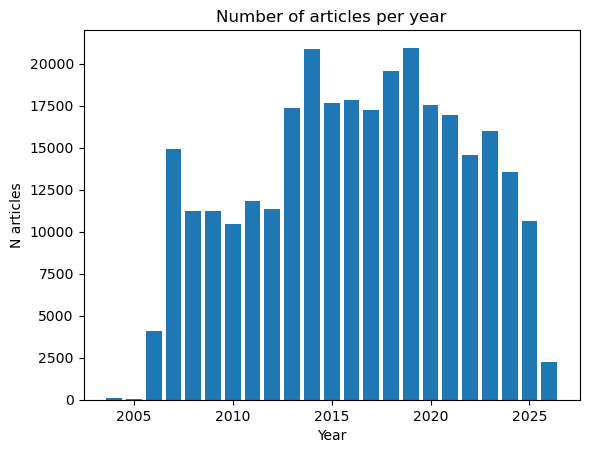

In [6]:
plt.bar(sorted(article_names.keys()), 
        height=n_articles)
plt.xlabel('Year')
plt.ylabel('N articles')
plt.title("Number of articles per year")
plt.show()

In [7]:
# Show the average file sizes as a proxy for article length to see if there is a change over time
cum_filesize = []
for year in sorted(list(article_names.keys())):
    size_sum = 0

    for month, articles in article_names[year].items():

        for article in articles:
            size_sum += os.path.getsize(f'../../articles/{year}/{month}/{article}')
    
    cum_filesize.append(size_sum)

print(cum_filesize)
print('Total dataset size:', sum(cum_filesize))

[256506, 212232, 15735779, 59996884, 47717674, 50313274, 48410086, 59502798, 57808300, 89222153, 110365461, 104568251, 101412281, 100926558, 118458305, 147169931, 171684902, 187773360, 177205882, 201083097, 176198818, 145346974, 30064278]
Total dataset size: 2201433784


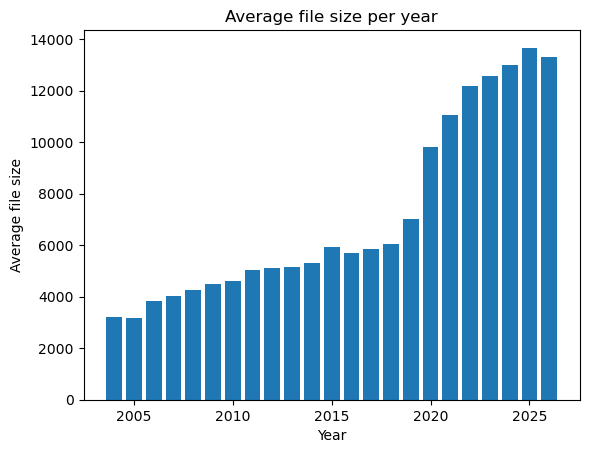

In [8]:
height = np.divide(np.array(cum_filesize), np.array(n_articles))

plt.bar(sorted(article_names.keys()), 
        height=height)
plt.xlabel('Year')
plt.ylabel('Average file size')
plt.title("Average file size per year")
plt.show()

### Insight in the file structure

In [9]:
article_text = {}

# for year in range(2009, 2010):
#     year = str(year)

for year in os.listdir('../../articles/'):    

    article_text[year] = {}

    for month in os.listdir(f'../../articles/{year}'):

        article_text[year][month] = {}

        for article_name in os.listdir(f'../../articles/{year}/{month}'):

            # Retrieve the flat text
            with open(f'../../articles/{year}/{month}/{article_name}', mode='r', encoding='utf-8') as file:
                
                article = json.load(file)

                text = ''

                for section in article['included']:

                    # Text is stored in two different types of blocks
                    if section['type'] in {'block-intro', 'block-text'}:

                        # Clean the text with the BeautifulSoup module
                        parsed = BeautifulSoup(section['attributes']['text'], "html.parser")
                        text += parsed.get_text()

                # Add text to dictionary, remove .json extension
                article_text[year][month][article_name[:-5]] = text

print(article_text.keys())

dict_keys(['2019', '2018', '2015', '2004', '2016', '2025', '2020', '2024', '2008', '2013', '2023', '2026', '2009', '2011', '2007', '2005', '2006', '2010', '2022', '2017', '2021', '2014', '2012'])


In [11]:
article_lengths = {}

for year in article_text.keys():

    article_lengths[year] = {}

    for month in article_text[year].keys():

        article_lengths[year][month] = {}

        for article in article_text[year][month].keys():
            
            # Split the text into individual words using nltk tokenizer
            tokenized = word_tokenize(article_text[year][month][article])

            article_lengths[year][month][article] = len(tokenized)

print(article_lengths['2009']['01'])

{'32220': 120, '24467': 70, '27350': 133, '40512': 42, '12553': 48, '26968': 90, '22128': 80, '9262': 94, '36376': 103, '18594': 268, '47192': 138, '2939': 95, '42127': 91, '19196': 75, '43528': 84, '8719': 376, '3033': 77, '938': 48, '45880': 79, '13627': 90, '26756': 99, '1461': 84, '33595': 45, '42986': 46, '10797': 100, '21098': 98, '41130': 102, '21868': 87, '48786': 56, '33966': 39, '22064': 46, '11172': 89, '29574': 50, '48186': 43, '43993': 85, '47258': 41, '27085': 84, '16095': 102, '38032': 93, '24992': 95, '27636': 92, '2320': 38, '20850': 88, '12786': 89, '31712': 159, '29367': 94, '3476': 296, '34615': 324, '29793': 47, '6427': 67, '34287': 44, '36832': 82, '46952': 93, '40307': 97, '24354': 270, '17174': 100, '41810': 38, '3218': 39, '15752': 43, '36077': 84, '27977': 115, '39864': 97, '26321': 43, '23872': 423, '9144': 46, '24568': 50, '27476': 102, '28632': 91, '26637': 40, '28309': 42, '28214': 132, '28890': 60, '2398': 47, '48691': 105, '24455': 104, '9157': 47, '4083

In [12]:
# Show the average number of words
cum_word_count = []

for year in sorted(list(article_lengths.keys())):
    
    size_sum = 0

    for month, articles in article_lengths[year].items():

        for article in articles:
            size_sum += article_lengths[year][month][article]
    
    cum_word_count.append(size_sum)

print(cum_word_count)

[2042, 2119, 308272, 1111248, 960854, 1218127, 1309887, 1784084, 1680611, 2528475, 3292079, 3210245, 3373554, 3614588, 4417932, 5317678, 5118229, 5571398, 5144121, 5911560, 5019169, 3726303, 676499]


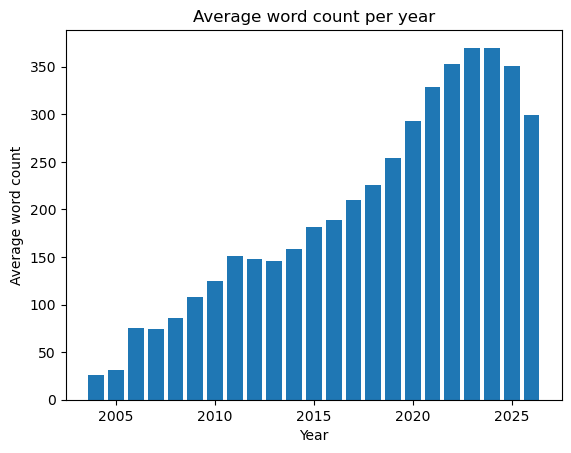

In [15]:
height = np.array(cum_word_count) / np.array(n_articles)

plt.bar(sorted(article_names.keys()), 
        height=height)
plt.xlabel('Year')
plt.ylabel('Average word count')
plt.title("Average word count per year")
plt.show()

In [ ]:
# Count the number of occurrences of each word
word_counts = {}

for year in article_text.keys():
    for month in article_text[year].keys():
        for article in article_text[year][month].keys():
            
            # Split the text into individual words using nltk tokenizer
            for word in word_tokenize(article_text[year][month][article]):

                # Count the words
                word_counts[word.lower()] = word_counts.get(word.lower(), 0) + 1

print(word_counts['voor'])

541814


In [37]:
# Show the most common words
sorted_counts = sorted(word_counts, key=word_counts.get, reverse=True)

print(f"{'Rank':<5} | {'Word':<10} | {'Count':>10}")
print("-" * 6, "-" * 12, "-" * 11)

rank  = 1

for word in sorted_counts[0:100]:
    print(f"{rank:<5} | {word:<10} | {word_counts[word]:>10}")
    rank += 1


Rank  | Word       |      Count
------ ------------ -----------
1     | de         |    3919164
2     | .          |    3556605
3     | het        |    1758794
4     | ,          |    1682306
5     | van        |    1549263
6     | een        |    1460237
7     | in         |    1330757
8     | en         |    1129170
9     | is         |     861295
10    | op         |     806136
11    | dat        |     751933
12    | te         |     594862
13    | ``         |     548487
14    | met        |     544618
15    | voor       |     541814
16    | zijn       |     540901
17    | ''         |     480730
18    | er         |     441526
19    | niet       |     422752
20    | die        |     387025
21    | ook        |     380386
22    | aan        |     370235
23    | om         |     354645
24    | bij        |     317370
25    | maar       |     315891
26    | hij        |     307426
27    | ze         |     266031
28    | nog        |     252542
29    | naar       |     252047
30    | 